# Titanic Data cleaning Project

## • Tools Used
- Python
- Pandas
- Matplotlib

## • Objectives
To prepare a reliable dataset by handling missing values, correcting inconsistencies, and addressing outliers, enabling accurate and meaningful insights from the data.

| Column        | Description                                                                 |
|---------------|-----------------------------------------------------------------------------|
| PassengerId   | Unique identifier for each passenger in the dataset.                        |
| Survived      | Survival indicator (0 = No, 1 = Yes).                                       |
| Pclass        | Passenger class (1 = 1st, 2 = 2nd, 3 = 3rd).                                |
| Name          | Full name of the passenger.                                                 |
| Sex           | Gender of the passenger ("male", "female").                                 |
| Age           | Age in years.                                                               |
| SibSp         | Number of siblings/spouses traveling with the passenger.                    |
| Parch         | Number of parents/children traveling with the passenger.                    |
| Ticket        | Ticket number (can contain letters and numbers).                            |
| Fare          | Ticket fare in British pounds.                                              |
| Cabin         | Cabin number.                                                               |
| Embarked      | Port of embarkation ("C" = Cherbourg, "Q" = Queenstown, "S" = Southampton). |
| Accompanied   | Whether a passenger was accompanied by family.                              |



---

### Libraries Used

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import Data

In [2]:
df = pd.read_csv(r"C:\Users\2B\Downloads\Titanic.csv")

### Information About Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    str    
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    str    
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Accompanied  891 non-null    str    
dtypes: float64(1), int64(4), str(8)
memory usage: 90.6 KB


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Accompanied
0,1,0,Third,"Braund, Mr. Owen Harris",MALE,22.0,1,0,A/5 21171,£7.25,NaN,S,Yes
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,£71.2833,C85,C,Yes
2,3,1,THIRD,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,£7.925,NaN,S,No
3,4,1,FIRST,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,£53.1,C123,S,Yes
4,5,0,Third,"Allen, Mr. William Henry",MALE,35.0,0,0,373450,£8.05,NaN,S,No


In [5]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Accompanied
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,£13.0,NaN,S,No
887,888,1,FIRST,"Graham, Miss. Margaret Edith",FEMALE,19.0,0,0,112053,£30.0,B42,S,No
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,£23.45,NaN,S,Yes
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,£30.0,C148,C,No
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,£7.75,NaN,Q,No


In [6]:
df.drop(columns=['PassengerId']).describe()

,Survived,Age,SibSp,Parch
count,891.000000,714.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594
std,0.486592,14.526497,1.102743,0.806057
min,0.000000,0.420000,0.000000,0.000000
25%,0.000000,20.125000,0.000000,0.000000
50%,0.000000,28.000000,0.000000,0.000000
75%,1.000000,38.000000,1.000000,0.000000
max,1.000000,80.000000,8.000000,6.000000


In [7]:
for col in df :
    print(f"column '{col}'")
    print("Namber of unique values :",len(df[col].value_counts()))
    print("Namber of Null values : ",df[col].isna().sum())
    print("------------------------------")

column 'PassengerId'
Namber of unique values : 891
Namber of Null values :  0
------------------------------
column 'Survived'
Namber of unique values : 2
Namber of Null values :  0
------------------------------
column 'Pclass'
Namber of unique values : 9
Namber of Null values :  0
------------------------------
column 'Name'
Namber of unique values : 891
Namber of Null values :  0
------------------------------
column 'Sex'
Namber of unique values : 4
Namber of Null values :  0
------------------------------
column 'Age'
Namber of unique values : 88
Namber of Null values :  177
------------------------------
column 'SibSp'
Namber of unique values : 7
Namber of Null values :  0
------------------------------
column 'Parch'
Namber of unique values : 7
Namber of Null values :  0
------------------------------
column 'Ticket'
Namber of unique values : 681
Namber of Null values :  0
------------------------------
column 'Fare'
Namber of unique values : 248
Namber of Null values :  0
-----

In [8]:
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

Number of duplicates: 0


notice the min value of the `Age` column is `0.42` while in the feature description it says it should be age in years, we should inspect the rows where the age is less than 1 to see if it's common

In [9]:
df[df['Age'] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Accompanied
78,79,1,SECOND,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,£29.0,NaN,S,Yes
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,£151.55,C22 C26,S,Yes
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,£19.2583,NaN,C,Yes
644,645,1,Third,"Baclini, Miss. Eugenie",FEMALE,0.75,2,1,2666,£19.2583,NaN,C,Yes
755,756,1,Second,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,£14.5,NaN,S,Yes
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,£8.5167,NaN,C,Yes
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,£18.75,NaN,S,Yes


checking if there's any other rows with age being a fraction

In [10]:
not_int_ages = df[df['Age'].notnull() & (df['Age'] % 1 != 0)]
not_int_ages['Age']

57     28.50
78      0.83
111    14.50
116    70.50
122    32.50
123    32.50
148    36.50
152    55.50
153    40.50
203    45.50
227    20.50
296    23.50
305     0.92
331    45.50
469     0.75
525    40.50
644     0.75
676    24.50
735    28.50
755     0.67
767    30.50
803     0.42
814    30.50
831     0.83
843    34.50
Name: Age, dtype: float64

In [11]:
categorical_features = ['Survived', 'Pclass', 'Sex', 'Embarked', 'Accompanied']

for col in categorical_features:
    print(f"Column {col}:")
    print(df[col].value_counts())
    print("------------------------------")

Column Survived:
Survived
0    549
1    342
Name: count, dtype: int64
------------------------------
Column Pclass:
Pclass
Third     169
THIRD     168
3         154
1          84
FIRST      69
SECOND     68
First      63
Second     61
2          55
Name: count, dtype: int64
------------------------------
Column Sex:
Sex
male      414
female    226
MALE      163
FEMALE     88
Name: count, dtype: int64
------------------------------
Column Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
------------------------------
Column Accompanied:
Accompanied
No     537
Yes    354
Name: count, dtype: int64
------------------------------


## Data Inspection Summary

After reviewing the dataset, the following issues were identified and should be addressed during data cleaning:

- **Pound sign in `Fare` column**: All values include a `£` symbol, preventing numeric analysis.
- **Inconsistent data in `Sex` column**: Some entries are lowercase (`male`), others uppercase (`MALE`).
- **Inconsistent data in `Pclass` column**: The column contains both numeric values (e.g., `1`) and string representations (`1st`, `FIRST`), causing ambiguity.
- **Age problem**: The `Age` column contains both decimals (`27.5`) and implausible values between 0 and 1 (e.g., `0.67`), which require standardization or correction.
- **`Accompanied` column redundancy**: `Accompanied` flag duplicates the information found in `Parch` and `SibSp`, adding no new insight.
- **Inconsistent datatypes**: Some columns have improper types (categorical values stored as `object`).
- **Null Values**: Some columns have a few null values like `Embarked` and `Age`, while the column `Cabin` has almost 80% null values.

# Data Cleaning

### PassengerId is just a unique identifier, so we use it as index

In [12]:
df.set_index('PassengerId', inplace=True)

### Dealing with inconsistent naming in `Pclass` column

In [13]:
Pclasses = {"1":1,"FIRST":1,"First":1,
            "2":2,"Second":2,"SECOND":2,
            "3":3,"Third":3,"THIRD":3}

df['Pclass']=df['Pclass'].map(Pclasses)

### Normalizing `Sex` column

In [14]:
df['Sex'] = df['Sex'].str.lower()

### Handling Decimals in the `Age` Column


In [15]:
df.loc[(df['Age'] >= 0) & (df['Age'] < 1), 'Age'] = np.nan
df.loc[(df['Age'].notnull()) & (df['Age'] % 1 != 0),'Age'] =(df.loc[(df['Age'].notnull()) & (df['Age'] % 1 != 0),'Age']).round()

### Removing the pound sign in `Fare` column

In [16]:
df['Fare'] = df['Fare'].str.replace('£','',regex=False).astype('float')

### Inconsistent Datatypes

In [17]:
for col in categorical_features :
    df[col] = df[col].astype('category')

### Outliers Detection

In [18]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numerical_features].describe()

,Age,SibSp,Parch,Fare
count,707.000000,891.000000,891.000000,891.000000
mean,29.978784,0.523008,0.381594,32.204208
std,14.308256,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.910400
50%,28.000000,0.000000,0.000000,14.454200
75%,38.500000,1.000000,0.000000,31.000000
max,80.000000,8.000000,6.000000,512.329200


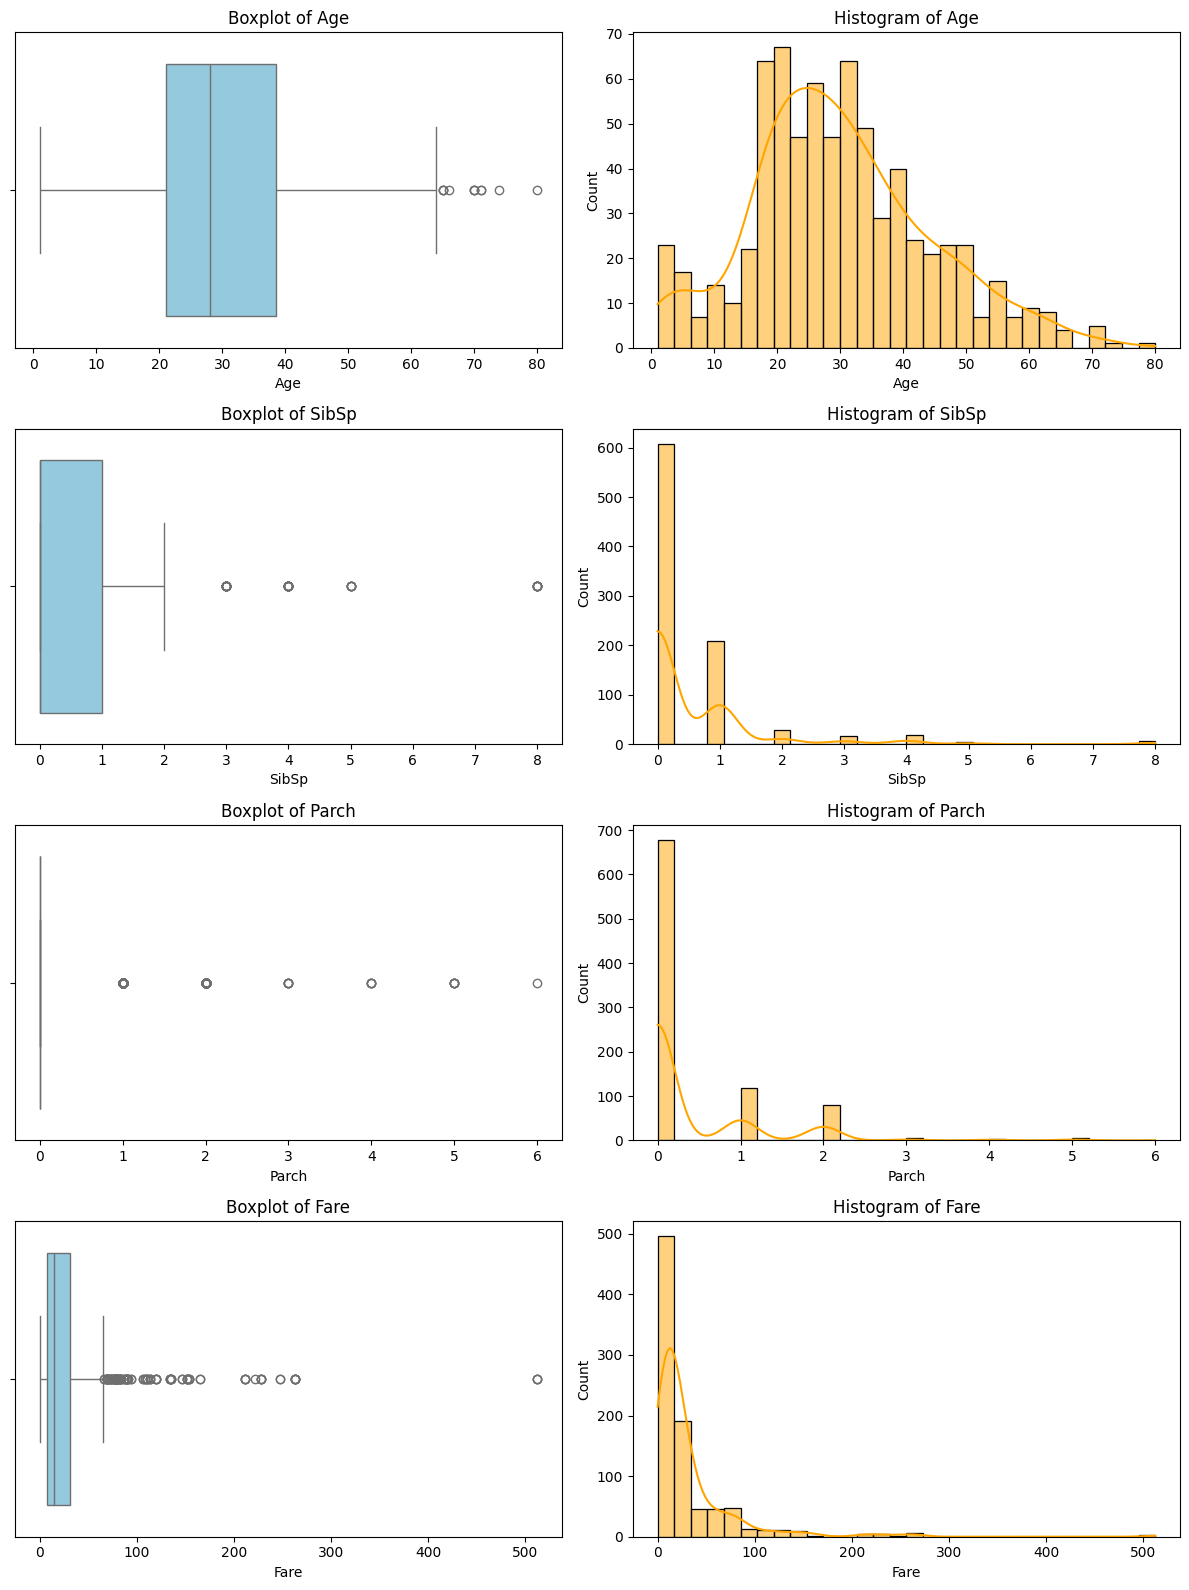

In [19]:
fig, axes = plt.subplots(len(numerical_features),2, figsize=(12, 4 * len(numerical_features)))

for i,col in enumerate(numerical_features):
    # boxplot
    sns.boxplot(x=df[col], ax=axes[i,0], color='skyblue')
    axes[i, 0].set_title(f'Boxplot of {col}')
    # Histogram
    sns.histplot(df[col], bins=30,ax=axes[i,1], kde=True, color='orange')
    axes[i, 1].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()


The outliers in `Age` are not outliers in this context, since the age `80` is completely normal

#### `SibSp` and `Parch`

In [20]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [21]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [22]:
df['SibSp_grouped'] = df['SibSp'].apply(lambda x: str(x) if x < 3 else '3+')
df['Parch_grouped'] = df['Parch'].apply(lambda x: str(x) if x < 3 else '3+')

In [23]:
df['SibSp_grouped'] = df['SibSp_grouped'].astype('category')
df['Parch_grouped'] = df['Parch_grouped'].astype('category')

In [24]:
df.drop(columns = ['SibSp', 'Parch'], inplace=True)

#### `Fare`

In [25]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 -Q1
print("Fare IQR:", IQR)

Fare IQR: 23.0896


In [26]:
lower_bound = Q1 - IQR * 1.5
upper_bound = Q3 + IQR * 1.5

fare_outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

In [27]:
print(fare_outliers[['Fare']])
print("Number of Fare outliers:",len(fare_outliers))

                 Fare
PassengerId          
2             71.2833
28           263.0000
32           146.5208
35            82.1708
53            76.7292
...               ...
847           69.5500
850           89.1042
857          164.8667
864           69.5500
880           83.1583

[116 rows x 1 columns]
Number of Fare outliers: 116


Detecting fare outliers within each `Pclass` is a more accurate approach, as each ticket class had vastly different typical fares.

In [28]:
outliers_indices = []

for cls in df['Pclass'].unique():
    fares = df.loc[df['Pclass']==cls ,'Fare']
    Q1 = fares.quantile(0.25)
    Q3 = fares.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = (fares < lower_bound) | (fares > upper_bound)
    outliers_indices.extend(df.loc[(df['Pclass'] == cls) & outlier_mask].index.tolist())

In [29]:
fare_outliers_by_class = df.loc[outliers_indices]
print(fare_outliers_by_class[['Pclass','Fare']])
print("Number of Fare outliers after conditioning on passenger class:", len(fare_outliers_by_class))

            Pclass     Fare
PassengerId                
14               3  31.2750
17               3  29.1250
26               3  31.3875
51               3  39.6875
60               3  46.9000
...            ...      ...
386              2  73.5000
616              2  65.0000
656              2  73.5000
666              2  73.5000
755              2  65.0000

[79 rows x 2 columns]
Number of Fare outliers after conditioning on passenger class: 79


#### Handling Outliers

Outliers are data points that stand out from the rest of the dataset and can result from real variability, rare events, or errors in data collection. While outliers can sometimes distort statistical analysis or models, they may also carry important information about the process being studied.

For this analysis, our goal is to **understand the data rather than build predictive models**, so we make it a priority to avoid removing or altering valid outlier values. Outlier detection is valuable for understanding the range and behavior of the data, but unless there is strong evidence of error or irrelevance, we **retain all outliers** to preserve the original story and patterns within the dataset.

By exploring and visualizing outliers, we gain deeper insight while keeping our dataset as close as possible to its real-world structure.

### Handling Null values


In [30]:
null_count = df.isnull().sum()
null_null_percentages = (null_count / len(df)) * 100

data = pd.DataFrame({'count':null_count,'percentage':null_null_percentages})
null_summary = data[data['count'] > 0]
null_summary

,count,percentage
Age,184,20.650954
Cabin,687,77.104377
Embarked,2,0.224467


Since the `Cabin` column contains nearly 80% missing values, it offers little to no information and can be safely removed from the dataset.


In [31]:
df.drop(columns='Cabin', inplace=True)

#### `Embarked`

In [32]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].value_counts().idxmax())

#### `Age`
- Because the age distribution has some skew and the mean and median are very similar, using the median is preferred for imputation since it is less affected by extremes.

In [33]:
df['Age'] = df['Age'].fillna(int(df['Age'].median()))

### Dropping redundant column

In [34]:
df.drop(columns='Accompanied', inplace=True)

In [35]:
df.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,SibSp_grouped,Parch_grouped
PassengerId,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,1,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,1,0
3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,0,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,1,0
5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,0,0


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Survived       891 non-null    category
 1   Pclass         891 non-null    category
 2   Name           891 non-null    str     
 3   Sex            891 non-null    category
 4   Age            891 non-null    float64 
 5   Ticket         891 non-null    str     
 6   Fare           891 non-null    float64 
 7   Embarked       891 non-null    category
 8   SibSp_grouped  891 non-null    category
 9   Parch_grouped  891 non-null    category
dtypes: category(6), float64(2), str(2)
memory usage: 33.5 KB
